In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import os
from scipy import stats
from scipy.stats import f_oneway
from pingouin import rm_anova
from pathlib import Path
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
# set variables for plots
sns.set_context('talk', font_scale=0.8)
fig_width, fig_height = 4,3

dpi = 300

In [3]:
# regex for splitting filename to get characteristics
# filename -> environment - height - flight path - index (1 or 2)

pattern = r'([a-z]+)(\d+m)([a-z]+)(\d)'

In [4]:
project_dir = Path.cwd().parent

scoreq_data = project_dir / 'data' / 'results' / 'scoreq_outputs_lufs.jsonl'
versa_data = project_dir / 'data' / 'results' / 'versa_outputs_lufs.jsonl'
versa_split_data = project_dir / 'data' / 'results' / 'versa_outputs_split.jsonl'
scoreq_split_data = project_dir / 'data' / 'results' / 'scoreq_outputs_split.jsonl'
subj_data = project_dir / 'data' / 'results' / 'subj_study_results.csv'

In [5]:
# set to True to exclude 5m recordings
# run file with this on TRUE and FALSE

EXCLUDE_5M = True

# set graphs folder and suffix based on flag
if EXCLUDE_5M:
    graphs = project_dir / 'graphs' / 'no5m'
    suffix = '_no5m'
else:
    graphs = project_dir / 'graphs' / 'full'
    suffix = '_full'


In [6]:
os.makedirs(graphs, exist_ok=True)

HELPER FUNCTIONS

In [7]:
# gets margin of error from t-table

def get_margin_of_error(data):
    if len(data) < 2: return 0
    se = stats.sem(data)
    t_star = stats.t.ppf(0.975, len(data)-1)
    return t_star * se

In [8]:
# gets summary stats grouped by a characteristic column

def get_stats(df, score_col, count_col, *group_cols):
    return df.groupby(list(group_cols)).agg(
        mos=(score_col, 'mean'),
        std=(score_col, 'std'),
        sample_size=(count_col, 'sum'),
        ci95=(score_col, get_margin_of_error)
    ).reset_index()

In [9]:
# plots stats grouped by a characteristic, with labelled errorbars

def plot_stats(attr, df, ax):
    for value in df[attr].unique():
        subset = df[df[attr] == value]
        
        ax.errorbar(
            x=subset[attr].str.capitalize(), 
            y=subset['mos'], 
            yerr=subset['ci95'], 
            fmt='o', 
            # color=colors[value],
            capsize=5,
            markersize=7,
            label=value.capitalize(),
            capthick=2,
        )
    y_offset = 0.03
    for i, row in df.iterrows():
        ax.text(
            x=i,                             
            y=(row['mos'] + row['ci95']) + y_offset,       
            s=f"{row['mos'] + row['ci95']:.2f}",   
            ha='center',                     
            va='bottom',                     
            fontsize=8,
            # fontweight='bold',
            color='black'
        )
    
        ax.text(
            x=i,                             
            y=(row['mos'] - row['ci95']) - y_offset*1.3,       
            s=f"{row['mos'] - row['ci95']:.2f}",   
            ha='center',                     
            va='top',                     
            fontsize=8,
            # fontweight='bold',
            color='black'
        )
    ax.set_xlabel(' '.join(attr.split('_')).capitalize())

    handles, labels = ax.get_legend_handles_labels()
    new_handles = [h[0] for h in handles]
    
    ax.legend(
        handles=new_handles, 
        labels=labels, 
        numpoints=1, 
        handlelength=0, 
        markerscale=1.2,
        borderpad=1.0,
        handletextpad=1.2
    )
    ax.set_axisbelow(True)

In [10]:
# plots an interaction between 2 attributes

def plot_interaction(x_attr, hue_attr, df, ax):
    stats = df.groupby([x_attr, hue_attr]).agg(
        mos=('mos', 'mean'),
        ci95=('mos', get_margin_of_error)
    ).reset_index()

    for hue_val in stats[hue_attr].unique():
        subset = stats[stats[hue_attr] == hue_val]
        ax.errorbar(
            x=subset[x_attr].str.capitalize(),
            y=subset['mos'],
            yerr=subset['ci95'],
            fmt='o-',          # the '-' connects the dots into a line
            capsize=5,
            markersize=7,
            capthick=2,
            label=hue_val.capitalize()
        )
    ax.set_xlabel(x_attr.replace('_', ' ').capitalize())
    ax.set_ylabel('MOS')

    handles, labels = ax.get_legend_handles_labels()
    new_handles = [h[0] for h in handles]
    
    ax.legend(
        handles=new_handles, 
        labels=labels, 
        numpoints=1, 
        handlelength=0, 
        markerscale=1.2,
        borderpad=1.0,
        handletextpad=1.2
    
    )
    ax.set_axisbelow(True)
    ax.grid(True, axis='y', alpha=0.5)

In [11]:
# similar to get_margin_of_error() but takes N argument - length of data

def get_margin_of_error_n(data, n):
    se = data.std() / np.sqrt(n)
    t_star = stats.t.ppf(0.975, n - 1)
    return t_star * se

In [12]:
scoreq_df = pd.read_json(scoreq_data, lines=True)
versa_df = pd.read_json(versa_data, lines=True)

In [13]:
# load split data
versa_split_df = pd.read_json(versa_split_data, lines=True)
scoreq_split_df = pd.read_json(scoreq_split_data, lines=True)

# get the base keys that have splits
split_base_keys = versa_split_df['key'].apply(lambda x: x.split('_norm')[0]).unique()

# remove those rows from the original data
scoreq_df = scoreq_df[~scoreq_df['key'].apply(lambda x: x.split('_')[0]).isin(split_base_keys)]
versa_df = versa_df[~versa_df['key'].apply(lambda x: x.split('_')[0]).isin(split_base_keys)]

# append split rows
scoreq_df = pd.concat([scoreq_df, scoreq_split_df], ignore_index=True)
versa_df = pd.concat([versa_df, versa_split_df], ignore_index=True)

In [14]:
# combine aggregated split data to rest

obj_df = pd.merge(scoreq_df, versa_df, on='key', how='inner')

In [15]:
obj_df

,key,scoreq_nr,scoreq_nmr,utmos,dns_overall,dns_p808,srmr,nisqa_mos_pred,nisqa_noi_pred,nisqa_dis_pred,nisqa_col_pred,nisqa_loud_pred
0,field1mhover1_norm.wav,0.904690,0.955730,1.406224,1.082467,2.111888,0.358791,1.007449,1.279662,2.819616,1.832405,1.680170
1,field1mhover2_norm.wav,0.918084,0.952650,1.381838,1.428645,2.121463,0.340993,0.900932,1.222288,2.774784,1.776589,1.653072
2,field3mflyby2_norm.wav,0.986306,0.834688,1.324665,1.085972,2.139016,0.467914,0.926146,1.197313,2.873263,1.905993,1.683512
3,field3mhover1_norm.wav,0.989776,0.930259,1.556566,1.062025,2.100251,0.381875,0.923348,1.238084,2.836697,1.831641,1.586102
4,field3mhover2_norm.wav,0.971598,0.882566,1.531579,1.072455,2.089343,0.404985,0.879743,1.287380,2.803922,1.767017,1.517317
5,field5mhover1_norm.wav,1.017753,0.864998,1.330215,1.068614,2.136278,0.444724,0.882445,1.190399,2.709938,1.605490,1.536452
6,field5mhover2_norm.wav,1.005048,0.862609,1.331945,1.079979,2.128156,0.424660,0.875396,1.216691,2.803305,1.687744,1.535741
7,garden1mflyby2_norm.wav,1.011787,1.054669,1.591654,1.076397,2.054317,0.545107,0.818240,1.205558,2.668311,1.590739,1.489238
8,garden1mhover1_norm.wav,0.937662,1.157502,1.418901,1.243932,2.144664,0.483047,1.021504,1.247678,2.849532,1.835944,1.690680
9,garden1mhover2_norm.wav,0.920738,1.155909,1.412369,1.415625,1.939968,0.535018,0.990000,1.210189,2.737142,1.809029,1.683994


In [16]:
drop = ['trial1_norm.wav', 'trial2_norm.wav']
index_to_drop = obj_df[obj_df['key'].isin(drop)].index
obj_df.drop(index_to_drop, inplace=True)

In [17]:
obj_df['key'] = obj_df['key'].apply(lambda x: x.split('_')[0])

In [18]:
obj_df['split_count'] = obj_df['key'].map(obj_df['key'].value_counts())

In [19]:
# extract flight details from filename and make columns

obj_df[['environment', 'height', 'flight_path', 'id']] = obj_df['key'].str.extract(pattern)

In [20]:
# rearrange columns so flight details are first, then filename, then Objective Analysis results

non_model_cols = ['environment', 'height', 'flight_path', 'id', 'key', 'split_count']
model_cols = [c for c in obj_df.columns if c not in non_model_cols]

obj_df = obj_df[non_model_cols + model_cols]

In [21]:
obj_df = obj_df.groupby(
    ['key', 'environment', 'height', 'flight_path', 'id', 'split_count']
)[model_cols].mean().reset_index()

In [23]:
obj_df.sample(3)

,key,environment,height,flight_path,id,split_count,scoreq_nr,scoreq_nmr,utmos,dns_overall,dns_p808,srmr,nisqa_mos_pred,nisqa_noi_pred,nisqa_dis_pred,nisqa_col_pred,nisqa_loud_pred
0,field1mflyby1,field,1m,flyby,1,2,0.965024,0.844125,1.384380,1.249293,2.169219,0.395241,0.843371,1.181268,2.724680,1.706928,1.510705
2,field1mhover1,field,1m,hover,1,1,0.904690,0.955730,1.406224,1.082467,2.111888,0.358791,1.007449,1.279662,2.819616,1.832405,1.680170
4,field3mflyby1,field,3m,flyby,1,2,1.020897,0.801548,1.404795,1.093505,2.237950,0.401450,0.888395,1.186351,2.802412,1.796218,1.568998


In [24]:
subj_df = pd.read_csv(subj_data)

In [25]:
# drop columns from csv that are added by GoListen but not needed

subj_df.drop(columns=['Unnamed: 0', 'Tags', 'Unnamed: 2', 'Unnamed: 3'], inplace=True)
subj_df.drop(0, inplace=True)

In [26]:
# transpose df to match objective format

subj_df_t = subj_df.T

In [27]:
subj_df_t.reset_index(inplace=True)
subj_df_t.rename(columns={'index': 'key'}, inplace=True)

In [28]:
subj_df_t['key'] = subj_df_t['key'].apply(lambda x: x.lower().replace(' ', ''))

In [29]:
response_cols = [c for c in subj_df_t.columns if c != 'key']
subj_df_t[response_cols] = subj_df_t[response_cols].astype(int)

In [30]:
# mean and standard deviation of responses for a given audio file

subj_df_t['mean'] = subj_df_t[response_cols].mean(axis=1)
subj_df_t['std'] = subj_df_t[response_cols].std(axis=1)

In [31]:
num_responses = subj_df.shape[0]

In [32]:
subj_df_t[['environment', 'height', 'flight_path', 'id']] = subj_df_t['key'].str.extract(pattern)

In [33]:
# rearrange columns so flight details are first, then filename, then Objective Analysis results

cols_to_move = ['environment', 'height', 'flight_path', 'id']
other_cols = [c for c in subj_df_t.columns if c not in cols_to_move]

subj_df_t = subj_df_t[cols_to_move + other_cols]

In [34]:
subj_df_t.sort_values(by='environment', inplace=True)
obj_df.sort_values(by='environment', inplace=True)

In [35]:
# remove rows from objective DF that aren't included in listening test

mask = obj_df['key'].isin(subj_df_t['key'])
obj_df = obj_df[mask].reset_index(drop=True)

In [36]:
# drop 5m files if EXCLUDE_5M is TRUE

if EXCLUDE_5M:
    obj_df = obj_df[obj_df['height'] != '5m']
    subj_df_t = subj_df_t[subj_df_t['height'] != '5m']

In [37]:
# melt DataFrames for easier analysis

subj_df_melted = subj_df_t.melt(id_vars=['environment', 'height', 'flight_path'], 
                    value_vars=[i for i in range(1, num_responses+1)],
                    var_name='subject', value_name='mos')


obj_df_melted = obj_df.melt(id_vars=['environment', 'height', 'flight_path', 'split_count'],
                    value_vars=model_cols,
                    var_name='model', value_name='mos_pred')

In [38]:
subj_df_melted['count'] = 1

In [39]:
subj_df_melted.sample(3)

,environment,height,flight_path,subject,mos,count
13,field,3m,flyby,2,4,1
74,field,1m,flyby,7,4,1
9,garden,3m,flyby,1,2,1


In [40]:
obj_df_melted.sample(3)

,environment,height,flight_path,split_count,model,mos_pred
73,field,3m,flyby,2,nisqa_mos_pred,0.888395
19,garden,1m,hover,1,scoreq_nmr,1.155909
54,garden,3m,flyby,1,dns_p808,2.151680


In [41]:
print(f'Objective study DF rows: {obj_df.shape[0]}')
print(f'Subjective study DF rows: {subj_df_t.shape[0]}')
print()
print(f'Objective study metric count: {len(model_cols)}')
print(f'Subjective study response count: {num_responses}')

Objective study DF rows: 12
Subjective study DF rows: 12

Objective study metric count: 11
Subjective study response count: 18


In [42]:
# group stats by 3 flight characteristics

stats_by_env = get_stats(subj_df_melted, 'mos', 'count', 'environment')
stats_by_height = get_stats(subj_df_melted, 'mos', 'count', 'height')
stats_by_flightpath = get_stats(subj_df_melted, 'mos', 'count', 'flight_path')

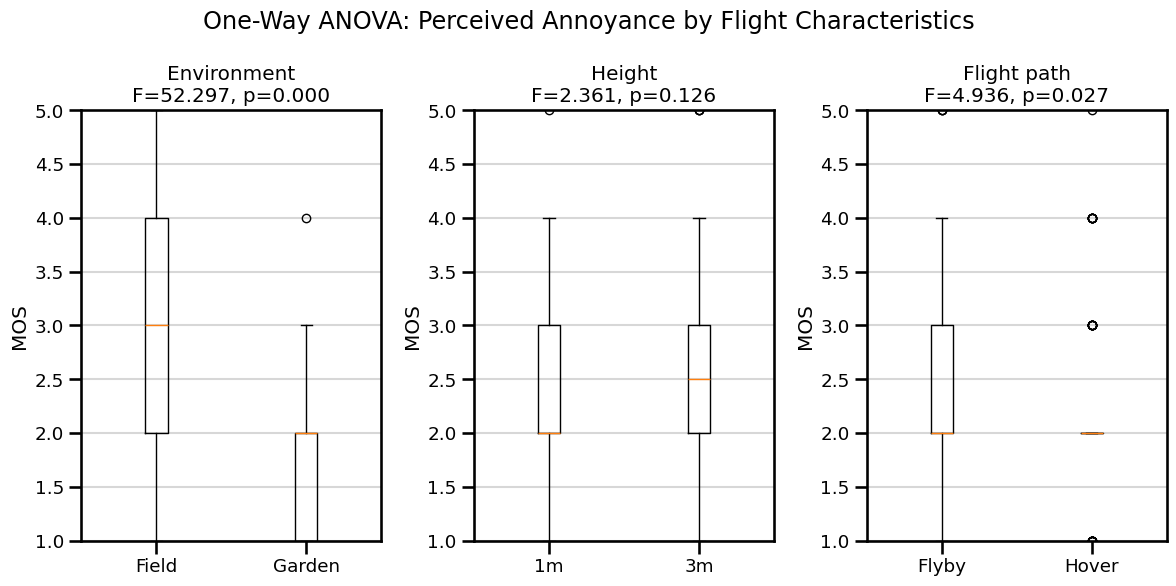

In [43]:
# plot ANOVA

fig, axs = plt.subplots(1, 3, figsize=(3 * fig_width, 2 * fig_height))

for ax, factor in zip(axs, ['environment', 'height', 'flight_path']):
    groups = [group['mos'].values for _, group in subj_df_melted.groupby(factor)]
    f, p = f_oneway(*groups)
    
    labels = [l.capitalize() for l in subj_df_melted[factor].unique()]
    ax.boxplot(groups, tick_labels=labels)
    
    ax.set_title(f'{factor.replace("_", " ").capitalize()}\nF={f:.3f}, p={p:.3f}')
    ax.set_ylabel('MOS')
    ax.set_ylim(1, 5)
    ax.grid(True, axis='y', alpha=0.5)

plt.suptitle('One-Way ANOVA: Perceived Annoyance by Flight Characteristics')
plt.tight_layout()
f = graphs / f'single_attribute_anova_boxplots{suffix}.png'
plt.savefig(f, dpi=dpi, bbox_inches='tight')
plt.show()

In [44]:
# perform Tukey test and save results to CSV

all_tukey = []
for factor in ['environment', 'height', 'flight_path']:
    print(f"\n--- {factor.upper()} ---")
    result = pairwise_tukeyhsd(subj_df_melted['mos'], subj_df_melted[factor])
    print(result)
    tukey_df = pd.DataFrame(data=result._results_table.data[1:], columns=result._results_table.data[0])
    tukey_df.insert(0, 'factor', factor)
    all_tukey.append(tukey_df)

pd.concat(all_tukey, ignore_index=True).to_csv(graphs / f'tukey_all{suffix}.csv', index=False)


--- ENVIRONMENT ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
 field garden  -0.8889   0.0 -1.1312 -0.6466   True
---------------------------------------------------

--- HEIGHT ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    1m     3m   0.2222 0.1259 -0.0629 0.5073  False
---------------------------------------------------

--- FLIGHT_PATH ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 flyby  hover  -0.3194 0.0274 -0.6029 -0.036   True
---------------------------------------------------


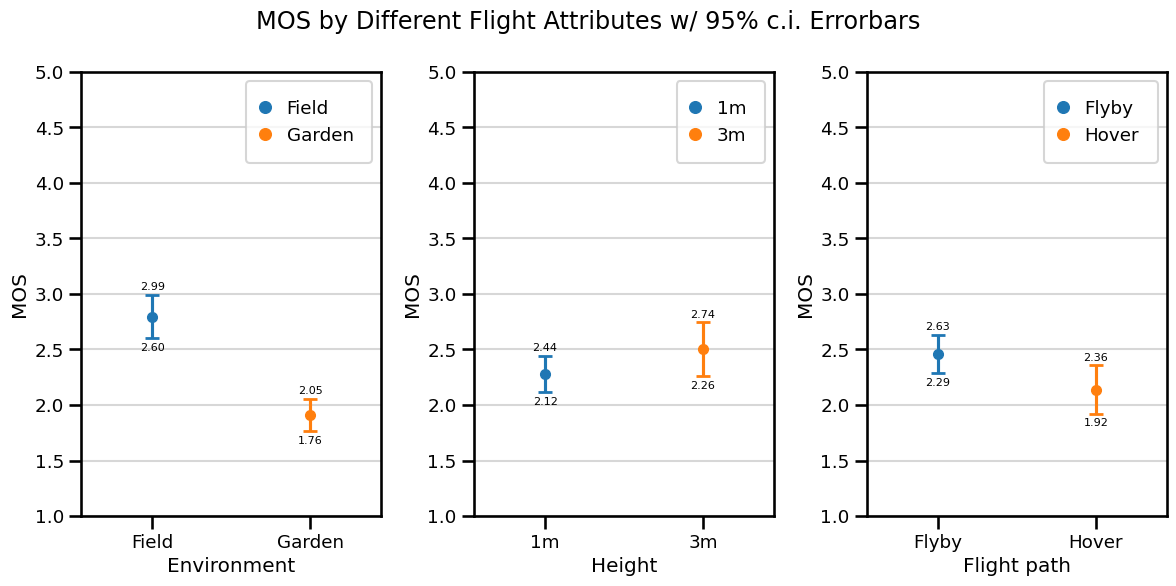

In [45]:
# plot MOS by the 3 characteristics with labelled errorbars

fig, axs = plt.subplots(1, 3, figsize=(3*fig_width, 2*fig_height))

for ax in axs:
    ax.set_ylim(1, 5)
    ax.set_ylabel('MOS')
    ax.margins(x=0.45)
    ax.grid(True, axis='y', alpha=0.5)

plt.suptitle('MOS by Different Flight Attributes w/ 95% c.i. Errorbars')
plt.subplots_adjust(wspace=0.4)

plot_stats('environment', stats_by_env, axs[0])
plot_stats('height', stats_by_height, axs[1])
plot_stats('flight_path', stats_by_flightpath, axs[2])

f = graphs / f'mos_by_attributes{suffix}.png'
plt.savefig(f, dpi=300, bbox_inches='tight')
fig.tight_layout()
plt.show()

In [46]:
# perform repeated measures ANOVA and save results to CSV

all_rm_anova = []
for factor in ['height', 'flight_path']:
    print(f"\n--- ENVIRONMENT x {factor.upper()} ---")
    result = rm_anova(
        data=subj_df_melted,
        dv='mos',
        within=['environment', factor],
        subject='subject'
    )
    print(result[['Source', 'F', 'p_unc', 'ng2']].to_string(index=False))
    result.insert(0, 'interaction', f'environment x {factor}')
    all_rm_anova.append(result[['interaction', 'Source', 'F', 'p_unc', 'ng2']])

pd.concat(all_rm_anova, ignore_index=True).to_csv(graphs / f'rm_anova_all{suffix}.csv', index=False)


--- ENVIRONMENT x HEIGHT ---
              Source         F    p_unc      ng2
         environment 23.575931 0.000148 0.303427
              height  3.392050 0.083027 0.024961
environment * height  0.883117 0.360511 0.003587

--- ENVIRONMENT x FLIGHT_PATH ---
                   Source         F    p_unc      ng2
              environment 19.710145 0.000359 0.260454
              flight_path  9.970067 0.005749 0.049205
environment * flight_path  2.693069 0.119155 0.013892


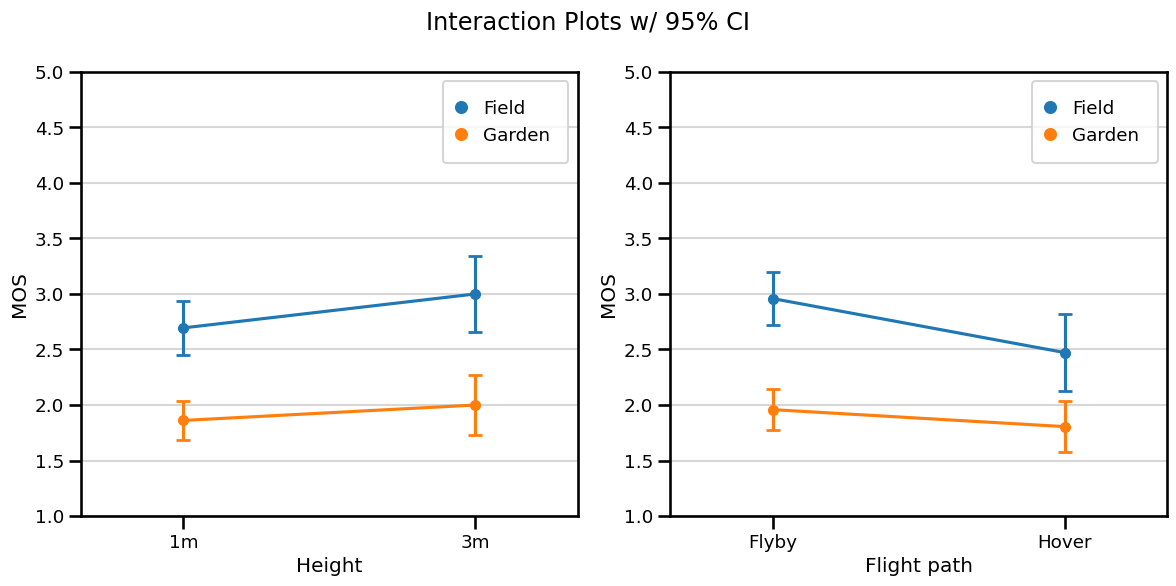

In [47]:
# plot changes in height and flight path by ENVIRONMENT

fig, axs = plt.subplots(1, 2, figsize=(3*fig_width, 2*fig_height))

plot_interaction('height', 'environment', subj_df_melted, axs[0])
plot_interaction('flight_path', 'environment', subj_df_melted, axs[1])
# plot_interaction('height', 'flight_path', subj_df_melted, axs[2])

for ax in axs:
    ax.set_ylim(1, 5)
    ax.margins(x=0.35)

plt.suptitle('Interaction Plots w/ 95% CI')
plt.subplots_adjust(wspace=1.6)

f = graphs / f'mos_attribute_interation_by_env{suffix}.png'
plt.savefig(f, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [48]:
# merge mean subjective MOS per stimulus with objective metrics
mean_subj = subj_df_t[['key', 'mean']].rename(columns={'mean': 'mean_mos'})
merged = obj_df.merge(mean_subj, on='key')

In [49]:
merged.sample(3)

,key,environment,height,flight_path,id,split_count,scoreq_nr,scoreq_nmr,utmos,dns_overall,dns_p808,srmr,nisqa_mos_pred,nisqa_noi_pred,nisqa_dis_pred,nisqa_col_pred,nisqa_loud_pred,mean_mos
11,garden3mflyby1,garden,3m,flyby,1,1,0.938101,1.053189,1.373226,1.082702,1.988449,0.593354,0.829603,1.176104,2.606846,1.464483,1.507727,2.055556
9,garden1mflyby2,garden,1m,flyby,2,1,1.011787,1.054669,1.591654,1.076397,2.054317,0.545107,0.818240,1.205558,2.668311,1.590739,1.489238,2.111111
10,garden1mflyby1,garden,1m,flyby,1,2,0.986751,1.060860,1.326523,1.099667,2.078672,0.599396,0.859876,1.191831,2.702723,1.620463,1.548459,1.722222


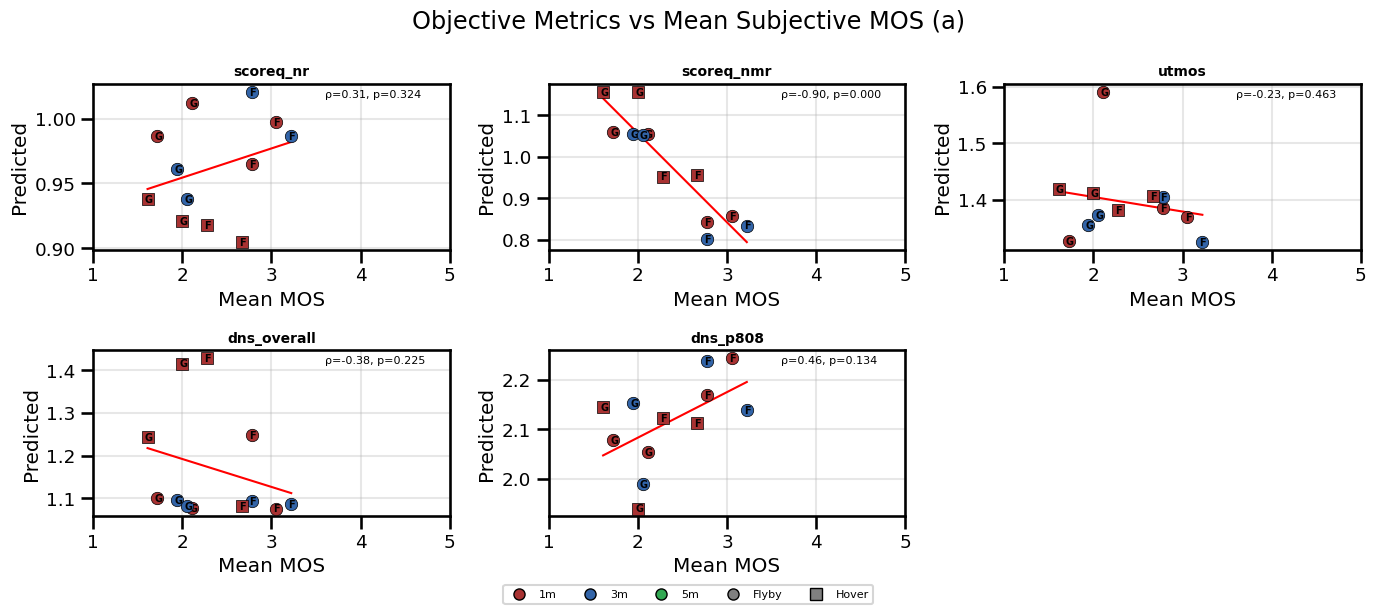

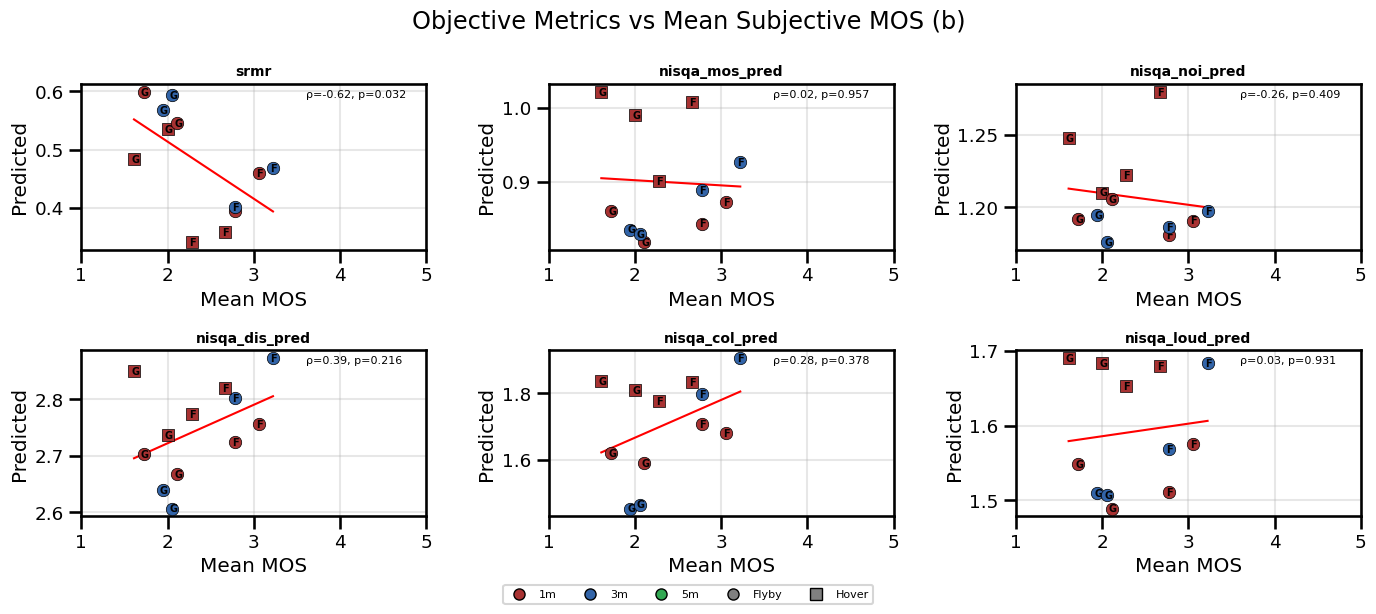

In [50]:
# plot data points for all models (split into 5 then 6 to keep figure sizes in check)
# each datapoint represents a unique audio recording
# regression line is plotted alongside data
# spearman correlation stats are printed


# custom legend
height_colors = {'1m': '#a83232', '3m': '#3264a8', '5m': '#32a852'}
markers = {'flyby': 'o', 'hover': 's'}
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#a83232', markeredgecolor='black', markersize=8, label='1m'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3264a8', markeredgecolor='black', markersize=8, label='3m'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#32a852', markeredgecolor='black', markersize=8, label='5m'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markeredgecolor='black', markersize=8, label='Flyby'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='grey', markeredgecolor='black', markersize=8, label='Hover'),
]

def plot_model_grid(models_subset, filename, flag=''):
    ncols = 3
    nrows = int(np.ceil(len(models_subset) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=((ncols + 0.5) * fig_width, nrows * fig_height))
    axs = axs.flatten()

    for i, model in enumerate(models_subset):
        ax = axs[i]
        for _, row in merged.iterrows():
            ax.scatter(
                x=row['mean_mos'],
                y=row[model],
                c=height_colors[row['height']],
                marker=markers[row['flight_path']],
                s=80,
                edgecolors='black',
                linewidths=0.5,
                zorder=3
            )
            ax.annotate(
                'F' if row['environment'] == 'field' else 'G',
                xy=(row['mean_mos'], row[model]),
                xytext=(-2, -2.5),
                textcoords='offset points',
                fontsize=7,
                color='black',
                fontweight='bold'
            )
        # regression line
        slope, intercept, *_ = stats.linregress(merged['mean_mos'], merged[model])
        x_line = np.linspace(merged['mean_mos'].min(), merged['mean_mos'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5, zorder=2)
        r, p = stats.spearmanr(merged['mean_mos'], merged[model])
        ax.annotate(f'ρ={r:.2f}, p={p:.3f}', xy=(0.65, 0.92), xycoords='axes fraction', fontsize=8)
        ax.set_title(model, fontsize=10, fontweight='bold')
        ax.set_xlabel('Mean MOS')
        ax.set_ylabel('Predicted')
        ax.set_xlim(1, 5)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    fig.legend(handles=legend_elements, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=8)
    plt.suptitle(f'Objective Metrics vs Mean Subjective MOS ({flag})')
    plt.tight_layout()
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.show()

# split model_cols into two halves and plot each
half = len(model_cols) // 2
plot_model_grid(model_cols[:half], graphs / f'obj_metrics_vs_mos_labelled_1{suffix}.png', flag='a')
plot_model_grid(model_cols[half:], graphs / f'obj_metrics_vs_mos_labelled_2{suffix}.png', flag='b')

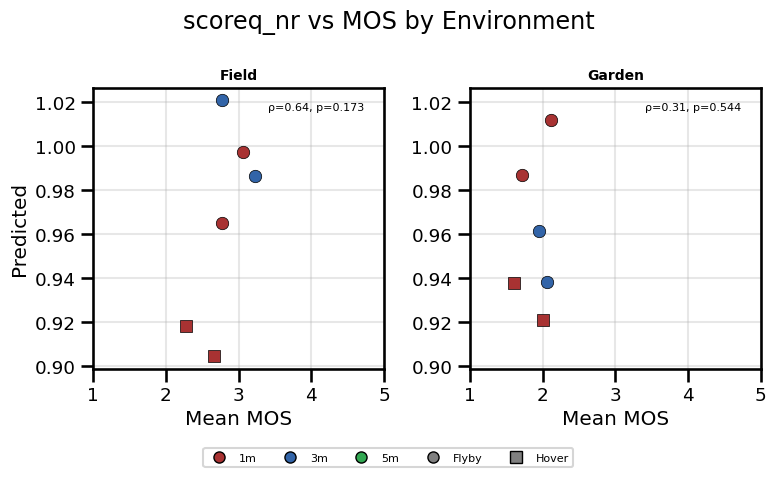

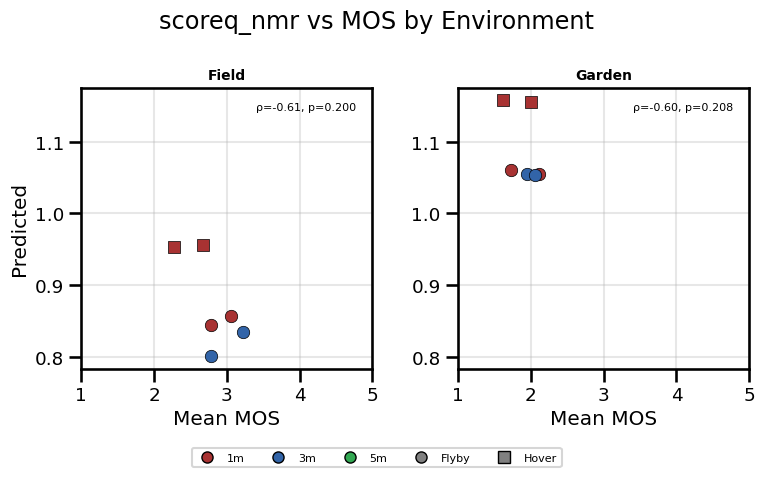

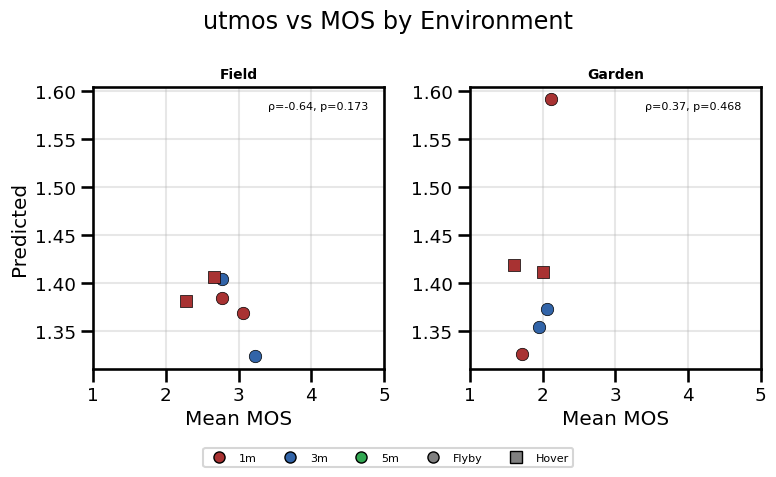

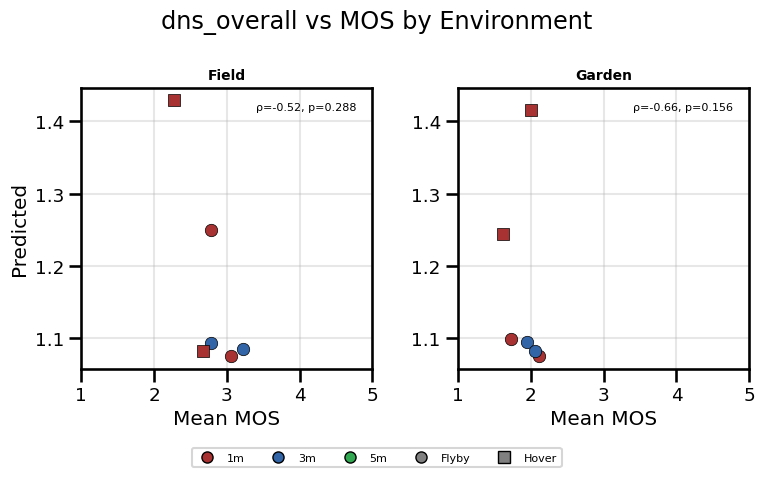

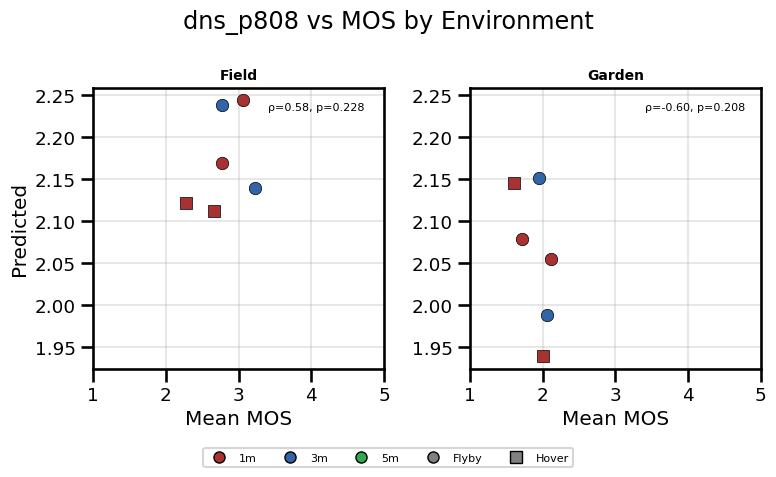

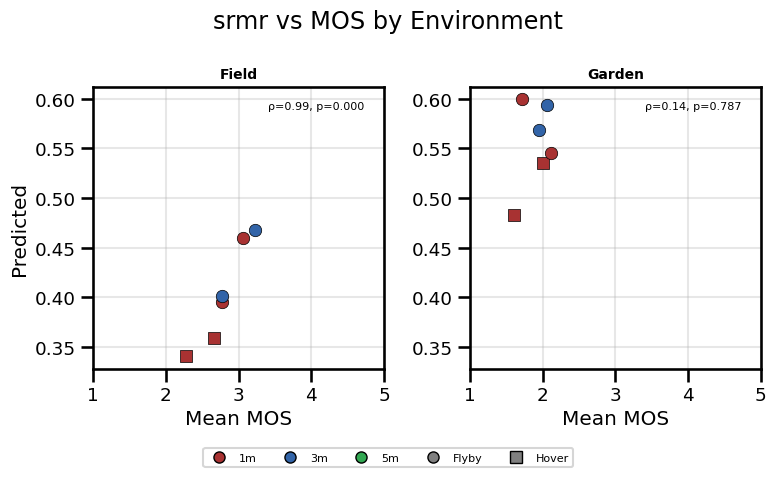

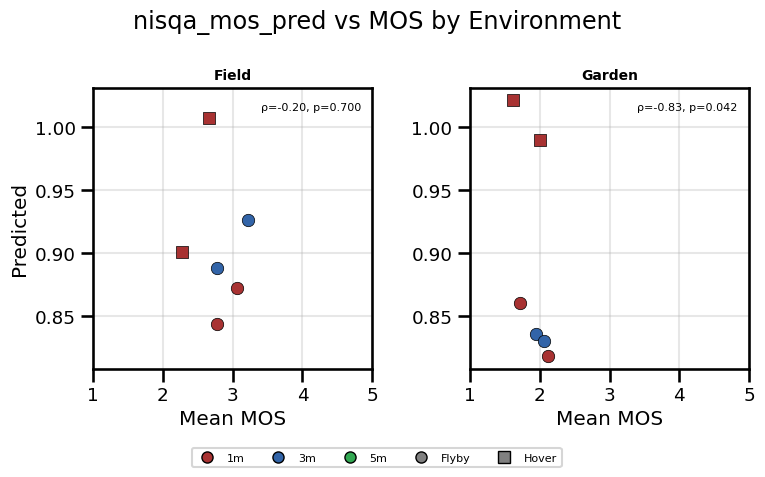

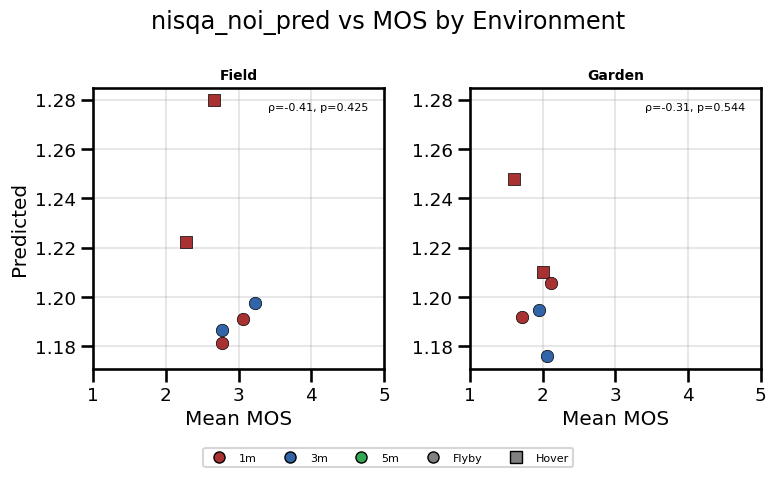

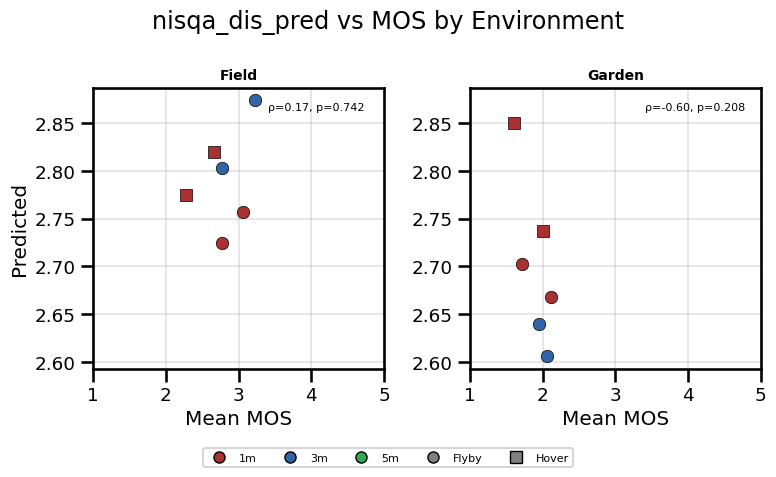

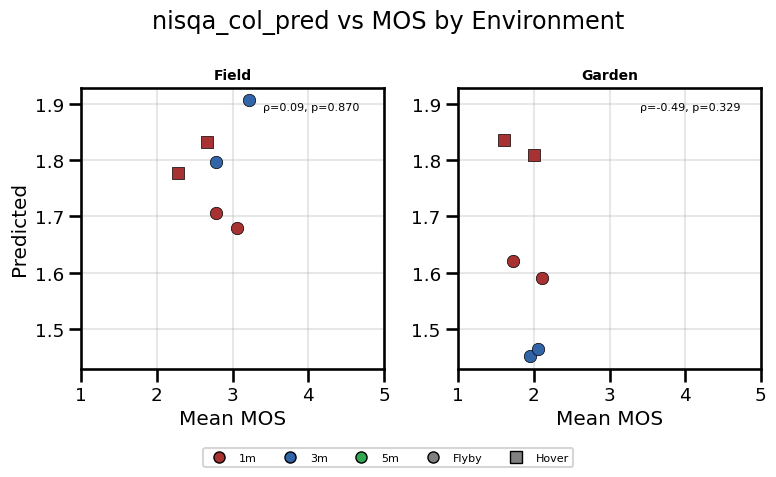

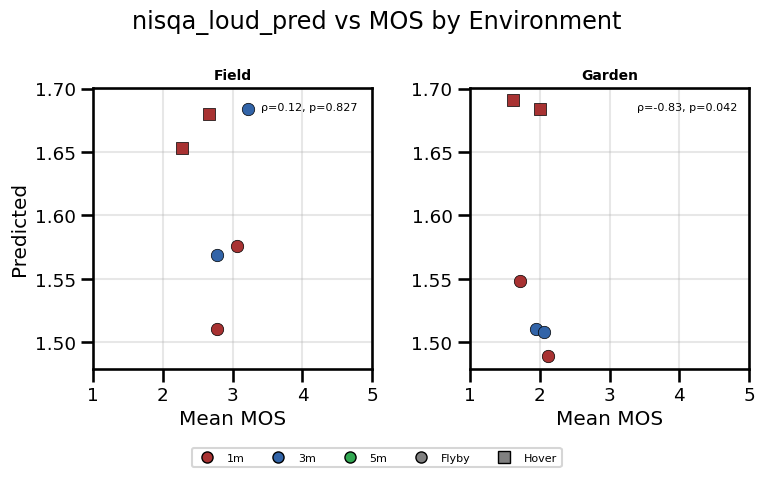

In [52]:
# plots faceted graphs for each model - field on left, garden on right
# all models are plotted, but only the 3 determined below (best, second best and worst) are used in the analysis

for model in model_cols:
    fig, axs = plt.subplots(1, 2, figsize=(2 * fig_width, 1.5 * fig_height), sharey=True)

    for ax in axs:
        ax.tick_params(labelleft=True)
    
    for ax, env in zip(axs, ['field', 'garden']):
        subset = merged[merged['environment'] == env]

        for _, row in subset.iterrows():
            ax.scatter(
                x=row['mean_mos'],
                y=row[model],
                c=height_colors[row['height']],
                marker=markers[row['flight_path']],
                s=80,
                edgecolors='black',
                linewidths=0.5,
                zorder=3
            )

        r, p = stats.spearmanr(subset['mean_mos'], subset[model])
        ax.annotate(f'ρ={r:.2f}, p={p:.3f}', xy=(0.6, 0.92), xycoords='axes fraction', fontsize=8)
        ax.set_title(env.capitalize(), fontsize=10, fontweight='bold')
        ax.set_xlabel('Mean MOS')
        ax.set_ylabel('Predicted' if ax == axs[0] else '')
        ax.set_xlim(1, 5)
        ax.grid(True, alpha=0.3)

    fig.legend(handles=legend_elements, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), fontsize=8)
    plt.suptitle(f'{model} vs MOS by Environment')
    
    plt.tight_layout()
    f = graphs / f'faceted_{model}_by_env{suffix}.png'
    plt.savefig(f, dpi=dpi, bbox_inches='tight')
    plt.show()

In [53]:
# compute spearman r between each metric and mean MOS
corr_data = merged[model_cols + ['mean_mos']]
corr_matrix, _ = stats.spearmanr(corr_data)
corr_df = pd.DataFrame(corr_matrix, index=corr_data.columns, columns=corr_data.columns)

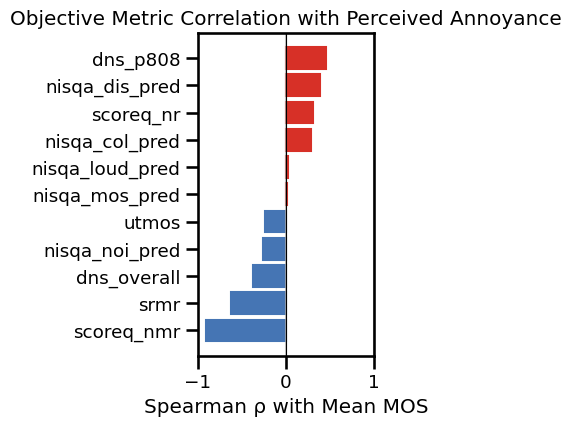

In [54]:
# extract just the mean_mos column, drop mean_mos correlating with itself
corr_with_mos = corr_df['mean_mos'].drop('mean_mos').sort_values()

fig, ax = plt.subplots(figsize=(fig_width, fig_height*1.5))
bars = ax.barh(corr_with_mos.index, corr_with_mos.values)

# colour by positive/negative
for bar, val in zip(bars, corr_with_mos.values):
    bar.set_color('#d73027' if val > 0 else '#4575b4')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel('Spearman ρ with Mean MOS')
ax.set_title('Objective Metric Correlation with Perceived Annoyance')
ax.grid(True, axis='x', alpha=0.7)

f = graphs / f'model_to_mos_correlation{suffix}.png'
plt.savefig(f, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [55]:
# create a series of absolute correlations
abs_corr = corr_with_mos.abs()

# find the strongest overall predictor (could be positive OR negative)
strongest_id = abs_corr.idxmax()
strongest_val = corr_with_mos[strongest_id] # Get the original value (+ or -)

# the "worst" is the one closest to 0
worst_id = abs_corr.idxmin()
worst_val = corr_with_mos[worst_id]

# second strongest - drop the best and find next highest abs correlation
abs_corr_remaining = abs_corr.drop(strongest_id)
second_strongest_id = abs_corr_remaining.idxmax()
second_strongest_val = corr_with_mos[second_strongest_id]

# print models and their correlation stat.
# these models are used for RQ2
print(f"The strongest model is {strongest_id.upper()} with a r = {strongest_val:.3f}")
print(f"Second strongest model: {second_strongest_id.upper()} with r = {second_strongest_val:.3f}")
print(f"The worst (weakest) model is {worst_id.upper()} with r = {worst_val:.3f}")

The strongest model is SCOREQ_NMR with a r =` -0.904
Second strongest model: SRMR with r = -0.620
The worst (weakest) model is NISQA_MOS_PRED with r = 0.018


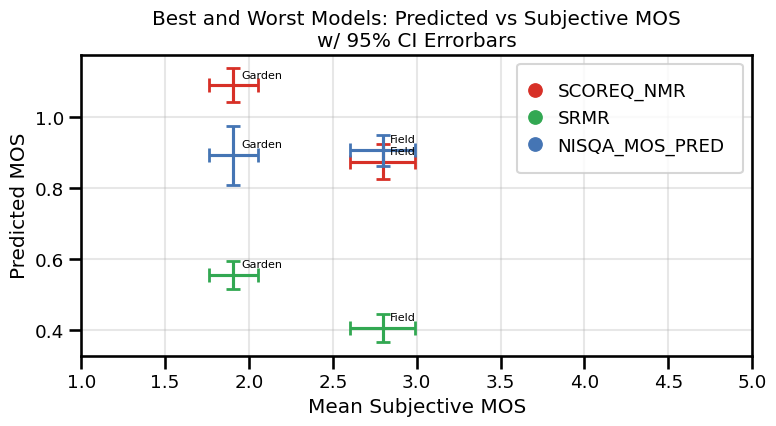

In [56]:
# plots model scores vs subjective MOS with errorbars for both

model_colors = {
    strongest_id: '#d73027',
    second_strongest_id: '#32a852',
    worst_id: '#4575b4',
}

model_labels = {
    strongest_id: strongest_id.upper(),
    second_strongest_id: second_strongest_id.upper(),
    worst_id: worst_id.upper(),
}

fig, ax = plt.subplots(figsize=(2 * fig_width, 1.5 * fig_height))

for model_id, color in model_colors.items():
    model_subset = obj_df_melted[obj_df_melted['model'] == model_id]
    obj_stats = model_subset.groupby('environment').apply(lambda g: pd.Series({
        'pred_mean': g['mos_pred'].mean(),
        'pred_ci': get_margin_of_error_n(g['mos_pred'], g['split_count'].sum()),
    }), include_groups=False).reset_index()

    combined = stats_by_env.rename(columns={'mos': 'mos_mean', 'ci95': 'mos_ci'}).merge(obj_stats, on='environment')

    for _, row in combined.iterrows():
        ax.errorbar(
            x=row['mos_mean'],
            y=row['pred_mean'],
            xerr=row['mos_ci'],
            yerr=row['pred_ci'],
            fmt='',
            color=color,
            ecolor=color,
            capsize=5,
            markersize=7,
            capthick=2,
            label=model_labels[model_id] if row['environment'] == 'field' else '_nolegend_',
        )
        ax.annotate(
            row['environment'].capitalize(),
            xy=(row['mos_mean'], row['pred_mean']),
            xytext=(5.5, 5.5),
            textcoords='offset points',
            fontsize=8,
            color='k',
        )

ax.set_xlabel('Mean Subjective MOS')
ax.set_ylabel('Predicted MOS')
ax.set_title('Best and Worst Models: Predicted vs Subjective MOS\nw/ 95% CI Errorbars')
ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
new_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d73027', markeredgecolor='#d73027', markersize=8, label=model_labels[strongest_id]),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#32a852', markeredgecolor='#32a852', markersize=8, label=model_labels[second_strongest_id]),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4575b4', markeredgecolor='#4575b4', markersize=8, label=model_labels[worst_id]),
]    
ax.legend(
    handles=new_handles, 
    labels=labels, 
    numpoints=1, 
    handlelength=0, 
    markerscale=1.2,
    borderpad=1.0,
    handletextpad=1.2
    
)


ax.set_xlim(1, 5)

plt.tight_layout()
f = graphs / f'model_vs_mos_errorbars{suffix}.png'
plt.savefig(f, dpi=dpi, bbox_inches='tight')
plt.show()